# Brazilian E-commerce Risk & Performance Analysis 
## About This Project
Olist is a Brazilian e-commerce platform with 99,441 real orders from 2016-2018. This project analyses order patterns, payment behaviour, 
delivery performance and customer reviews to identify business risks. 
Key questions: What is driving 1 star reviews? How are late deliveries affecting customer satisfaction?
Are cancellations linked to stock unavailability? 
These insights matter because unresolved delivery and cancellation issues directly threaten revenue and customer retention
- Source: Olist Brazilian E-commerce Dataset (Kaggle)
- 99,441 real orders from 2016-2018
- 5 CSV files used — orders, payments, reviews, customers, sellers
## Tools
Python, Pandas, Matplotlib

# Loading & Exploring Data

In [5]:
import pandas as pd
import numpy as np
orders =pd.read_csv("C:\\Users\\Rishitha\\OneDrive\\Desktop\\ds-projects\\olist_orders_dataset.csv")
customers = pd.read_csv("C:\\Users\\Rishitha\\OneDrive\\Desktop\\ds-projects\\olist_customers_dataset.csv")
order_items = pd.read_csv("C:\\Users\\Rishitha\\OneDrive\\Desktop\\ds-projects\\olist_order_items_dataset.csv")
order_payments =pd.read_csv("C:\\Users\\Rishitha\\OneDrive\\Desktop\\ds-projects\\olist_order_payments_dataset.csv")
order_reviews = pd.read_csv("C:\\Users\\Rishitha\\OneDrive\\Desktop\\ds-projects\\olist_order_reviews_dataset.csv")

In [6]:
print(orders.shape)
print(customers.shape)
print(order_items.shape)
print(order_payments.shape)
print(order_reviews.shape)

(99441, 8)
(99441, 5)
(112650, 7)
(103886, 5)
(99224, 7)


In [7]:
#missing values
print(orders.isnull().sum())
print(customers.isnull().sum())
print(order_items.isnull().sum())
print(order_payments.isnull().sum())
print(order_reviews.isnull().sum())

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date    

## Order Status Analysis

In [9]:
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

## Customer Review Analysis

In [11]:
order_reviews['review_score'].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

In [12]:
total_reviews = order_reviews['review_score'].count()
one_star = order_reviews['review_score'].value_counts()[1]
percentage = (one_star/total_reviews)*100
print(percentage)

11.51334354591631


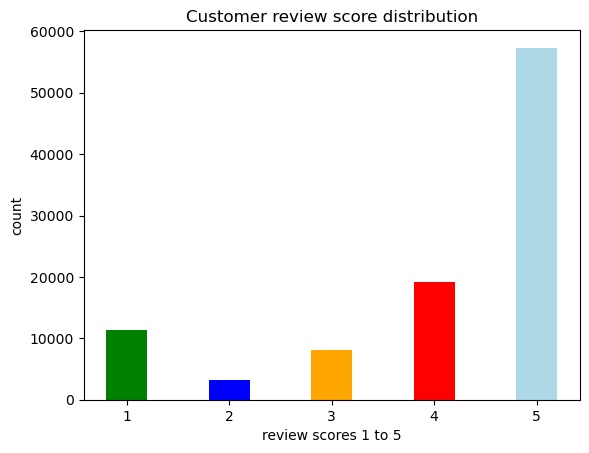

In [13]:
import matplotlib.pyplot as plt
review_score =order_reviews['review_score'].value_counts().sort_index()
plt.bar(review_score.index,review_score.values,width = 0.4,color =["green","blue","orange","red","lightblue"])
plt.title("Customer review score distribution")
plt.xlabel("review scores 1 to 5")
plt.ylabel("count")
plt.show()

majority of customers are happy (5 star dominates) but 1 star is the second most common score. That gap between 1 and 2 star is interesting — customers either love it or hate it, very few are mildly unhappy.

## Data Merging

In [16]:
df = pd.merge(orders,order_payments,on ='order_id')
df = pd.merge(df,order_reviews[['order_id','review_score']], on = 'order_id')
df = pd.merge(df,customers,on ='customer_id')
df.shape
print(df.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'review_score', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']


## Revenue Analysis

In [18]:
revenue = df['payment_value'].sum()
print(revenue) #₹1.59 crore in total revenue. 

15931654.41


In [19]:
Average_order_value = df['payment_value'].mean()
print(Average_order_value) # ₹153.67

153.6662365809196


In [20]:
paymentype = df['payment_type'].value_counts()
print(paymentype)

payment_type
credit_card    76600
boleto         19762
voucher         5783
debit_card      1529
not_defined        3
Name: count, dtype: int64


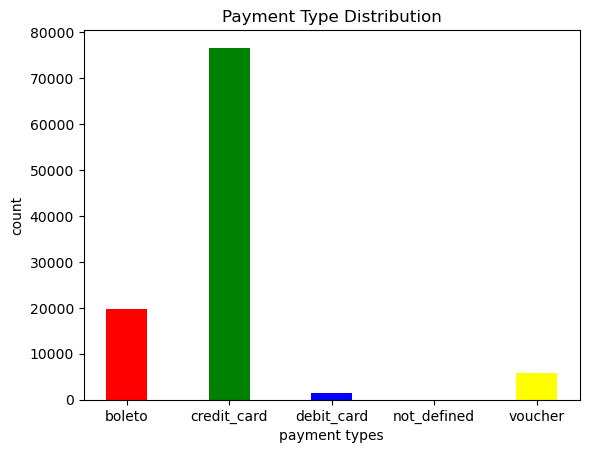

In [21]:
paymentype = df['payment_type'].value_counts().sort_index()
plt.bar(paymentype.index,paymentype.values,width=0.4, color =["red","green","blue","lightblue","yellow"])
plt.title("Payment Type Distribution")
plt.xlabel("payment types")
plt.ylabel("count")
plt.show()

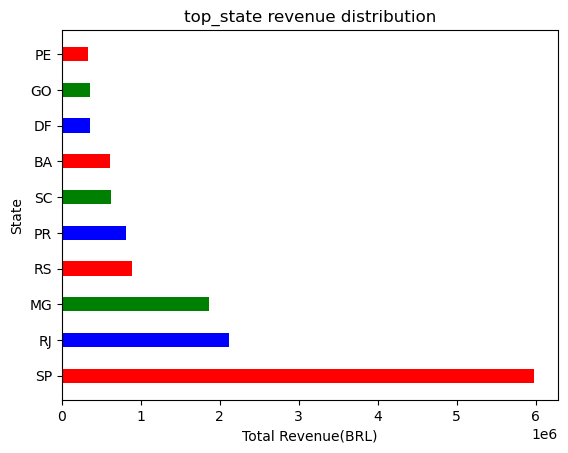

In [23]:
top_states= df.groupby('customer_state')['payment_value'].sum().sort_values(ascending= False).head(10)
plt.barh(top_states.index, top_states.values, height = 0.4,color =["red","blue","green"])
plt.title("top_state revenue distribution")
plt.xlabel("Total Revenue(BRL)")
plt.ylabel("State")
plt.show()

In [24]:
#monthly revenue trend.
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['month'] = df['order_purchase_timestamp'].dt.to_period('M')

In [25]:
monthly_revenue =df.groupby('month')['payment_value'].sum()
print(monthly_revenue)#Business grew 4,000x in 2 years.

month
2016-09        252.24
2016-10      58311.04
2016-12         19.62
2017-01     138094.79
2017-02     291640.31
2017-03     444630.88
2017-04     415356.28
2017-05     591744.13
2017-06     511934.95
2017-07     590442.90
2017-08     672045.83
2017-09     725660.41
2017-10     775634.57
2017-11    1191894.07
2017-12     868912.25
2018-01    1109540.36
2018-02     995258.01
2018-03    1151970.72
2018-04    1154780.44
2018-05    1147048.23
2018-06    1021867.29
2018-07    1055344.20
2018-08    1016508.29
2018-09       2172.93
2018-10        589.67
Freq: M, Name: payment_value, dtype: float64


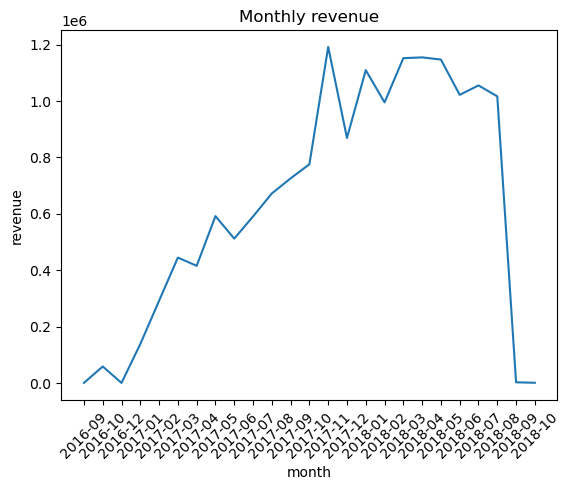

In [26]:
monthly_revenue =df.groupby('month')['payment_value'].sum()
plt.plot(monthly_revenue.index.astype(str), monthly_revenue.values)
plt.xticks(rotation=45)
plt.title("Monthly revenue")
plt.xlabel("month")
plt.ylabel("revenue")
plt.show()

## Delivery Performance

In [28]:
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date']) #turns the word into the number.
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])

In [29]:
df['delivery_delay'] =(df['order_delivered_customer_date']- df['order_estimated_delivery_date']).dt.days

In [30]:
print(df['delivery_delay'].describe())

count    100647.000000
mean        -11.935825
std          10.116939
min        -147.000000
25%         -17.000000
50%         -12.000000
75%          -7.000000
max         188.000000
Name: delivery_delay, dtype: float64


In [31]:
len(df[df['delivery_delay'] > 0])

6653

In [32]:
late = df[df['delivery_delay'] > 0]['review_score'].mean()
ontime = df[df['delivery_delay'] <= 0]['review_score'].mean()
print("Late delivery avg review:", round(late, 2))
print("On time avg review:", round(ontime, 2))

Late delivery avg review: 2.27
On time avg review: 4.29


##  Cancellation & Risk Analysis

In [33]:
#seller fraud risk, chargeback risk, friendly fraud risk
total_orders = orders['order_status'].count()
cancelled = orders[orders['order_status'] == 'canceled'].shape[0]
cancellation_rate = round((cancelled / total_orders) * 100, 2)

print(f"Total Orders: {total_orders}")
print(f"Cancelled Orders: {cancelled}")
print(f"Cancellation Rate: {cancellation_rate}%")

Total Orders: 99441
Cancelled Orders: 625
Cancellation Rate: 0.63%


## Late Delivery Rate

In [58]:
total_delivered = df['delivery_delay'].dropna().shape[0]
late_orders = df[df['delivery_delay'] > 0].shape[0]
late_pct = round((late_orders / total_delivered) * 100, 2)

print(f"Total Delivered Orders: {total_delivered}")
print(f"Late Orders: {late_orders}")
print(f"Late Delivery Rate: {late_pct}%")

Total Delivered Orders: 100647
Late Orders: 6653
Late Delivery Rate: 6.61%


## Geographic Risk — High Revenue Concentration

In [60]:
total_revenue = df['payment_value'].sum()
sp_revenue = df[df['customer_state'] == 'SP']['payment_value'].sum()
sp_concentration = round((sp_revenue / total_revenue) * 100, 2)

print(f"SP Revenue Concentration: {sp_concentration}%")
print("Risk: Over-reliance on single state creates revenue vulnerability")

# States with highest cancellation risk
cancelled_by_state = df[df['order_status'] == 'canceled'].groupby('customer_state')['order_id'].count().sort_values(ascending=False).head(5)
print("\nTop 5 States by Cancellations:")
print(cancelled_by_state)

SP Revenue Concentration: 37.57%
Risk: Over-reliance on single state creates revenue vulnerability

Top 5 States by Cancellations:
customer_state
SP    347
RJ     85
MG     62
RS     25
PR     24
Name: order_id, dtype: int64


## Key Findings & Recommendations

1. 6.61% of orders were delivered late, with a maximum delay of 188 days. 
Late orders average 2.27 stars vs 4.29 for on-time orders — delivery 
directly drives customer satisfaction. Customers ordering for specific 
occasions are most affected. Recommendation: improve logistics partnerships 
and set realistic delivery estimates. Proactive delay notifications should 
be implemented.

2. Cancellation rate is low at 0.63% (625 orders), but SP accounts for 55% 
of all cancellations despite generating 38% of revenue. 625 cancellations 
may be linked to 609 unavailable orders — sellers accepting orders without 
confirming stock availability. Recommendation: implement real-time inventory 
checks before order confirmation.

3. SP state generates 37.57% of total revenue — dangerous geographic 
concentration. Marketing and seller strategies working in SP should be 
studied and rolled out to RJ and MG which are the next highest revenue 
states.

4. 74% of payments use credit card — highest chargeback fraud exposure. 
Customers may claim fraudulent transactions after receiving products. 
Recommendation: implement 3-strike refund policy and real-time transaction 
monitoring.

5. Business grew 4,000x in revenue between 2016 and 2018 — 
rapid growth increases fraud and logistics risk if controls 
don't scale at the same pace.

6. Automated alert recommended — if late delivery rate exceeds 8%, 
trigger immediate logistics review.